# Exercise 1: Exploratory Data Analysis

* Get the CalCofi data set  from https://www.kaggle.com/datasets/sohier/calcofi
* Work with the bottle.csv data.
* Use Julia to clean it (see below)
* Use Julia to do the  list of EDA tasks listed below
* Produce a report showing your code and your results
* Submit your project following the submission guidelines


In [2]:
println("Here we Julia!")

Here we Julia!


In [169]:
import Pkg; 
# Pkg.add("DataFrames");
# Pkg.add("CSV");
# Pkg.add("Statistics");
# Pkg.add("Plots");


using DataFrames
using CSV
using Statistics
using Plots


Pkg.offline(true)


## dataShape
Get shape of the data

In [137]:
bt = CSV.read("./dat/bottle.csv", DataFrame);

In [94]:
# @show(bt)
@show(typeof(bt))
@show(size(bt))
@show(names(bt))

typeof(bt) = DataFrame
size(bt) = (864863, 74)
names(bt) = ["Cst_Cnt", "Btl_Cnt", "Sta_ID", "Depth_ID", "Depthm", "T_degC", "Salnty", "O2ml_L", "STheta", "O2Sat", "Oxy_µmol/Kg", "BtlNum", "RecInd", "T_prec", "T_qual", "S_prec", "S_qual", "P_qual", "O_qual", "SThtaq", "O2Satq", "ChlorA", "Chlqua", "Phaeop", "Phaqua", "PO4uM", "PO4q", "SiO3uM", "SiO3qu", "NO2uM", "NO2q", "NO3uM", "NO3q", "NH3uM", "NH3q", "C14As1", "C14A1p", "C14A1q", "C14As2", "C14A2p", "C14A2q", "DarkAs", "DarkAp", "DarkAq", "MeanAs", "MeanAp", "MeanAq", "IncTim", "LightP", "R_Depth", "R_TEMP", "R_POTEMP", "R_SALINITY", "R_SIGMA", "R_SVA", "R_DYNHT", "R_O2", "R_O2Sat", "R_SIO3", "R_PO4", "R_NO3", "R_NO2", "R_NH4", "R_CHLA", "R_PHAEO", "R_PRES", "R_SAMP", "DIC1", "DIC2", "TA1", "TA2", "pH2", "pH1", "DIC Quality Comment"]


74-element Vector{String}:
 "Cst_Cnt"
 "Btl_Cnt"
 "Sta_ID"
 "Depth_ID"
 "Depthm"
 "T_degC"
 "Salnty"
 "O2ml_L"
 "STheta"
 "O2Sat"
 ⋮
 "R_PRES"
 "R_SAMP"
 "DIC1"
 "DIC2"
 "TA1"
 "TA2"
 "pH2"
 "pH1"
 "DIC Quality Comment"

# dataType

Gives data type of each column in the dataset


In [111]:
column_types = Dict(name => eltype(bt[!, name]) for name in names(bt))
@show(column_types)

column_types = Dict{String, Type}("pH2" => Union{Missing, Float64}, "SiO3uM" => Union{Missing, Float64}, "LightP" => Union{Missing, Float64}, "MeanAp" => Union{Missing, Int64}, "Cst_Cnt" => Int64, "TA2" => Union{Missing, Float64}, "R_O2" => Union{Missing, Float64}, "R_DYNHT" => Union{Missing, Float64}, "TA1" => Union{Missing, Float64}, "O2Satq" => Union{Missing, Int64}, "DarkAs" => Union{Missing, Float64}, "PO4q" => Union{Missing, Int64}, "R_SVA" => Union{Missing, Float64}, "NH3q" => Union{Missing, Int64}, "R_NO3" => Union{Missing, Float64}, "T_qual" => Union{Missing, Int64}, "R_SALINITY" => Union{Missing, Float64}, "O2ml_L" => Union{Missing, Float64}, "S_prec" => Union{Missing, Int64}, "STheta" => Union{Missing, Float64}, "Phaqua" => Union{Missing, Int64}, "Phaeop" => Union{Missing, Float64}, "IncTim" => Union{Missing, String31}, "Sta_ID" => String15, "S_qual" => Union{Missing, Int64}, "SiO3qu" => Union{Missing, Int64}, "R_CHLA" => Union{Missing, Float64}, "DIC1" => Union{Missing, Flo

Dict{String, Type} with 74 entries:
  "pH2"        => Union{Missing, Float64}
  "SiO3uM"     => Union{Missing, Float64}
  "LightP"     => Union{Missing, Float64}
  "MeanAp"     => Union{Missing, Int64}
  "Cst_Cnt"    => Int64
  "TA2"        => Union{Missing, Float64}
  "R_O2"       => Union{Missing, Float64}
  "R_DYNHT"    => Union{Missing, Float64}
  "TA1"        => Union{Missing, Float64}
  "O2Satq"     => Union{Missing, Int64}
  "DarkAs"     => Union{Missing, Float64}
  "PO4q"       => Union{Missing, Int64}
  "R_SVA"      => Union{Missing, Float64}
  "NH3q"       => Union{Missing, Int64}
  "R_NO3"      => Union{Missing, Float64}
  "T_qual"     => Union{Missing, Int64}
  "R_SALINITY" => Union{Missing, Float64}
  "O2ml_L"     => Union{Missing, Float64}
  "S_prec"     => Union{Missing, Int64}
  ⋮            => ⋮

# count_missing(col)
Counts number of missing data in a given col (Column).

In [65]:
# function count_missing(df::DataFrame, column_name::Symbol)
function count_missing(df::DataFrame, column_name::String)
    missing_count = count(ismissing, df[!, column_name])
    # println("Registros faltantes en columna $column_name: $missing_count")
    return missing_count
end

@show count_missing(bt,"Cst_Cnt")
@show count_missing(bt,"SiO3uM")
@show count_missing(bt,"pH2")

#Another form
# function count_missing(df::DataFrame, column_name::Symbol)
#     missing_count_A = count(ismissing, df[!, column_name])
#     println("Registros faltantes en columna $column_name: $missing_count_A")
# end
# count_missing(bt,:Cst_Cnt)
# count_missing(bt,:SiO3uM)
# count_missing(bt,:pH2)


count_missing(bt, "Cst_Cnt") = 0
count_missing(bt, "SiO3uM") = 510772
count_missing(bt, "pH2") = 864853


864853

# dataMissingPercentage()

Finds missing percentage of each column.

In [162]:
function dataMissingPercentage(df::DataFrame)
    nrows = nrow(df)
    missingPercentage=[count_missing(df,name) / nrows * 100 for name in names(df)]
    # missingPercentage=[count_missing(df,name) for name in names(df)]
    return missingPercentage
end

dataMissingPercentage(bt)

74-element Vector{Float64}:
  0.0
  0.0
  0.0
  0.0
  0.0
  1.2675996082616552
  5.475318056154559
 19.501585800294382
  6.092178761260454
 23.54002888318728
  ⋮
  0.0
 85.89302583183695
 99.76886512661542
 99.97409994415301
 99.75903698042349
 99.97294369165984
 99.99884374750683
 99.99028747905737
 99.99364061128757

# deleteColumns(threshold) 

Delete all the columns which have missing percent less than given threshold.

In [164]:

function deleteColumns(df::DataFrame,threshold::Int64)
    nrows = nrow(df)
    mpv = dataMissingPercentage(df)
    i=1
    dfnew=copy(df)
    for name in names(df)
       if mpv[i] > (100-threshold)
        # println("Borrado ",name," ", mpv[i])
        select!(dfnew, Not(name))
      # else
      # println("Se queda ",name," ", mpv[i])
       end
       i=i+1   
    end 
    return dfnew
end

# function deleteColumns(df::DataFrame,threshold::Int64)
#   dfnew=copy(df)
#   # select!(dfnew, Not(names(dfnew)[eltype.(dfnew) .== String]))
#   select!(dfnew, Not(names(dfnew)[eltype.(dfnew) .== String]))
#   return dfnew
# end

bt_thd=deleteColumns(bt,10)
@show(size(bt))
@show(size(bt_thd))
# @show(names(df_thd))


size(bt) = (864863, 74)
size(bt_thd) = (864863, 52)


(864863, 52)

# calculateCorrelation()

Creates correlation matrix between columns.

In [166]:
function calculateCorrelation(df::DataFrame)
    dfnew=copy(df)
    # Eliminar el `Union{Missing}` y mantener solo el tipo base
    for col in names(dfnew)
        col_type = eltype(dfnew[!, col])
        if !(col_type <: Union{Number, Missing})
            select!(dfnew, Not(col))
        end
    end
    @show size(dfnew)

    # Rellenando valores Missing con la media de la columna
    df_filled = mapcols(x -> coalesce.(x, mean(skipmissing(x))), dfnew)
    @show size(df_filled)

    # df_clean = dropmissing(df_filled)
    # @show size(df_clean)

    corr_matrix = cor(Matrix(df_filled))  # Convertir el DataFrame a una matriz numérica
    
    return corr_matrix
end

cmbt = calculateCorrelation(bt)
cmbt_thd = calculateCorrelation(bt_thd)

size(dfnew) = (864863, 70)
size(df_filled) = (864863, 70)
size(df_clean) = (864863, 70)
size(dfnew) = (864863, 50)
size(df_filled) = (864863, 50)
size(df_clean) = (864863, 50)


50×50 Matrix{Float64}:
  1.0           0.999345     -0.162222    …  -0.161961    -0.0420854
  0.999345      1.0          -0.161617       -0.161348    -0.046796
 -0.162222     -0.161617      1.0             0.999994    -0.00413708
  0.0887829     0.0895807    -0.678628       -0.677289     0.00210352
 -0.189893     -0.187243      0.543326        0.542121    -0.000220042
  0.146288      0.14457      -0.532769    …  -0.53124      0.0210291
 -0.0857483    -0.0854084     0.551689        0.550416    -0.00262854
  0.122815      0.121268     -0.512682       -0.511196     0.019254
  0.132695      0.130957     -0.507193       -0.505668     0.0211274
 -0.00184103   -0.00214028   -0.12941        -0.128976     0.080134
  ⋮                                       ⋱               
  0.120155      0.118613     -0.511864       -0.510375     0.0195573
 -0.0178161    -0.0174072     0.422068        0.421443    -0.0171924
 -0.107526     -0.107148      0.42284         0.421761    -0.0195108
 -0.000543621   0.0

In [167]:
@show(size(cmbt))
@show(cmbt[1:10,1:10])

@show(size(cmbt_thd))
@show(cmbt_thd[1:10,1:10])

size(cmbt) = (70, 70)
cmbt[1:10, 1:10] = [1.0 0.9993450094378044 -0.16222238751806053 0.08878292114394946 -0.1898925540587261 0.1462875856585653 -0.08574833155363527 0.12281513425750924 0.13269543285012672 -0.0018410285643033727; 0.9993450094378044 1.0 -0.16161667042737526 0.08958069567452359 -0.18724345823378102 0.14456984772629172 -0.08540835481739179 0.12126783059138431 0.13095672183252913 -0.002140278302175322; -0.16222238751806053 -0.16161667042737526 1.0 -0.6786277885271654 0.5433259710800871 -0.5327689616417053 0.5516892005271152 -0.512681767277825 -0.5071930808281877 -0.1294100011809326; 0.08878292114394946 0.08958069567452359 -0.6786277885271654 1.0 -0.48996716591512623 0.7127312543673204 -0.804294859725953 0.7451306841867172 0.6968990414982569 0.23728462244791834; -0.1898925540587261 -0.18724345823378102 0.5433259710800871 -0.48996716591512623 1.0 -0.7220557948785781 0.6011370702885891 -0.7084071405308671 -0.7389748915689405 -0.22701997311276115; 0.1462875856585653 0.14456984

10×10 Matrix{Float64}:
  1.0          0.999345    -0.162222  …   0.122815   0.132695  -0.00184103
  0.999345     1.0         -0.161617      0.121268   0.130957  -0.00214028
 -0.162222    -0.161617     1.0          -0.512682  -0.507193  -0.12941
  0.0887829    0.0895807   -0.678628      0.745131   0.696899   0.237285
 -0.189893    -0.187243     0.543326     -0.708407  -0.738975  -0.22702
  0.146288     0.14457     -0.532769  …   0.965814   0.972406   0.277417
 -0.0857483   -0.0854084    0.551689     -0.724045  -0.694328  -0.216636
  0.122815     0.121268    -0.512682      1.0        0.993336   0.289051
  0.132695     0.130957    -0.507193      0.993336   1.0        0.284471
 -0.00184103  -0.00214028  -0.12941       0.289051   0.284471   1.0

# displayCorrelation() 

Dislpay correlation using heatmap.

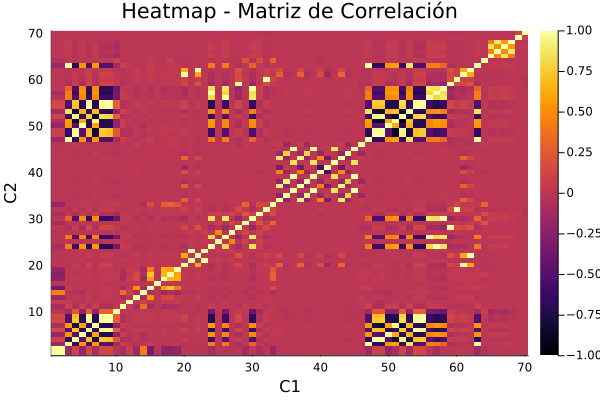

"e:\\GITHUB\\Diplomado-ia\\julia\\src\\student_submissions\\exploratory_data_analysis\\cortes_marcos\\fig\\1.matriz_de_correlacion.png"

In [184]:
heatmap_plot = heatmap(cmbt, 
        title="Heatmap - Matriz de Correlación", 
        xlabel="C1", 
        ylabel="C2", 
        color=:blues, 
        clims=(-1, 1),  # Establecer límites de color para el rango de -1 a 1
        c=:auto)  # Escala automática de colores

        display(heatmap_plot)

        savefig(heatmap_plot2, "./fig/1.matriz_de_correlacion.png")


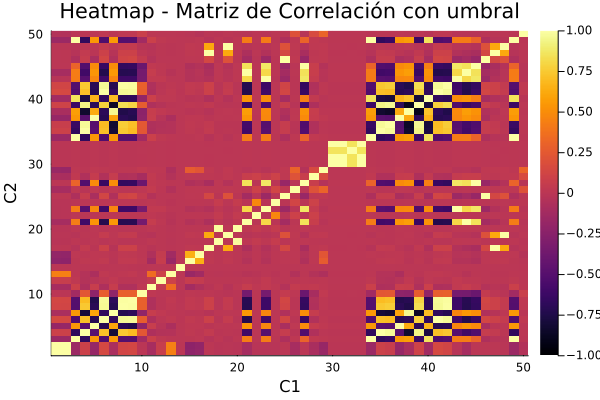

"e:\\GITHUB\\Diplomado-ia\\julia\\src\\student_submissions\\exploratory_data_analysis\\cortes_marcos\\fig\\1.matriz_de_correlacion_umbral.png"

In [185]:
heatmap_plot2 = heatmap(cmbt_thd, 
title="Heatmap - Matriz de Correlación con umbral", 
xlabel="C1", 
ylabel="C2", 
color=:blues, 
clims=(-1, 1),  # Establecer límites de color para el rango de -1 a 1
c=:auto)  # Escala automática de colores

display(heatmap_plot2)

savefig(heatmap_plot2, "./fig/1.matriz_de_correlacion_umbral.png")


# removeOutliersIQR() 

Using interquartile range delete all the outliers from the numerical columns.
